In [10]:
# ============================================================
# BLOQUE 1 - CARGA, LIMPIEZA E INTEGRACIÓN DEL DATASET MAESTRO
# Proyecto Olist - Satisfacción del cliente
# ============================================================

import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, asin

# ------------------------------------------------------------
# 1. RUTAS DE ARCHIVOS
# Ajusta estas rutas si estás en otra carpeta
# ------------------------------------------------------------

customers_path = "/content/olist_customers_dataset.csv"
geolocation_path = "/content/olist_geolocation_dataset.csv"
order_items_path = "/content/olist_order_items_dataset.csv"
reviews_path = "/content/olist_order_reviews_dataset.csv"
orders_path = "/content/olist_orders_dataset.csv"
products_path = "/content/olist_products_dataset.csv"
sellers_path = "/content/olist_sellers_dataset.csv"
translation_path = "/content/product_category_name_translation.csv"

# ------------------------------------------------------------
# 2. CARGA DE TABLAS
# ------------------------------------------------------------

customers = pd.read_csv(customers_path)
geo = pd.read_csv(geolocation_path)
items = pd.read_csv(order_items_path)
reviews = pd.read_csv(reviews_path)
orders = pd.read_csv(orders_path)
products = pd.read_csv(products_path)
sellers = pd.read_csv(sellers_path)
translation = pd.read_csv(translation_path)

# ------------------------------------------------------------
# 3. REVISIÓN RÁPIDA
# ------------------------------------------------------------

print("Shapes originales:")
print("customers:", customers.shape)
print("geo:", geo.shape)
print("items:", items.shape)
print("reviews:", reviews.shape)
print("orders:", orders.shape)
print("products:", products.shape)
print("sellers:", sellers.shape)
print("translation:", translation.shape)

print("\nNulos principales:")
for name, df in {
    "orders": orders,
    "reviews": reviews,
    "items": items,
    "products": products,
    "customers": customers,
    "sellers": sellers,
    "geo": geo
}.items():
    print(f"\n{name}")
    print(df.isna().sum().sort_values(ascending=False).head(10))

# ------------------------------------------------------------
# 4. CONVERSIÓN DE FECHAS
# ------------------------------------------------------------

date_cols_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols_orders:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"], errors="coerce")
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"], errors="coerce")
items["shipping_limit_date"] = pd.to_datetime(items["shipping_limit_date"], errors="coerce")

# ------------------------------------------------------------
# 5. FILTRO INICIAL DE ÓRDENES
# Nos quedamos con pedidos entregados, porque queremos estudiar
# satisfacción post-entrega y tiempos logísticos reales.
# ------------------------------------------------------------

orders_delivered = orders[orders["order_status"] == "delivered"].copy()

# Eliminamos filas sin fecha real de entrega o fecha estimada
orders_delivered = orders_delivered.dropna(
    subset=["order_delivered_customer_date", "order_estimated_delivery_date"]
).copy()

print("\nPedidos entregados válidos:", orders_delivered.shape)

# ------------------------------------------------------------
# 6. GEOLOCALIZACIÓN
# La tabla geo tiene múltiples filas por zip prefix.
# Promediamos lat/lng por zip code prefix.
# ------------------------------------------------------------

geo_agg = (
    geo.groupby("geolocation_zip_code_prefix", as_index=False)
       .agg(
           geolocation_lat=("geolocation_lat", "mean"),
           geolocation_lng=("geolocation_lng", "mean")
       )
)

print("\nGeolocalización agregada:", geo_agg.shape)

# ------------------------------------------------------------
# 7. PRODUCTOS + TRADUCCIÓN
# ------------------------------------------------------------

products = products.merge(
    translation,
    on="product_category_name",
    how="left"
)

products["product_category_final"] = products["product_category_name_english"].fillna(
    products["product_category_name"]
)

# ------------------------------------------------------------
# 8. ITEMS ENRIQUECIDOS CON PRODUCTOS
# Aquí todavía estamos a nivel de ítem.
# ------------------------------------------------------------

items_prod = items.merge(
    products[[
        "product_id",
        "product_category_final",
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm"
    ]],
    on="product_id",
    how="left"
)

# Variables auxiliares
items_prod["item_volume_cm3"] = (
    items_prod["product_length_cm"].fillna(0) *
    items_prod["product_height_cm"].fillna(0) *
    items_prod["product_width_cm"].fillna(0)
)

# ------------------------------------------------------------
# 9. AGREGACIÓN A NIVEL DE PEDIDO
# Esto es clave: una fila = una orden
# ------------------------------------------------------------

order_items_agg = (
    items_prod.groupby("order_id", as_index=False)
    .agg(
        n_items=("order_item_id", "count"),
        n_sellers=("seller_id", "nunique"),
        total_price=("price", "sum"),
        total_freight=("freight_value", "sum"),
        avg_item_price=("price", "mean"),
        avg_freight=("freight_value", "mean"),
        total_weight_g=("product_weight_g", "sum"),
        avg_weight_g=("product_weight_g", "mean"),
        total_volume_cm3=("item_volume_cm3", "sum")
    )
)

# Categoría principal del pedido = la más frecuente dentro de la orden
main_category = (
    items_prod.groupby(["order_id", "product_category_final"])
    .size()
    .reset_index(name="freq")
    .sort_values(["order_id", "freq"], ascending=[True, False])
    .drop_duplicates(subset=["order_id"])
    [["order_id", "product_category_final"]]
    .rename(columns={"product_category_final": "main_category"})
)

# Seller principal del pedido:
# si solo hay un seller, se conserva; si hay varios, queda NaN
seller_count = (
    items_prod.groupby("order_id")["seller_id"]
    .nunique()
    .reset_index(name="seller_count_check")
)

main_seller = (
    items_prod.groupby("order_id")["seller_id"]
    .first()
    .reset_index()
)

main_seller = main_seller.merge(seller_count, on="order_id", how="left")
main_seller["seller_id"] = np.where(
    main_seller["seller_count_check"] == 1,
    main_seller["seller_id"],
    np.nan
)
main_seller = main_seller[["order_id", "seller_id"]]

order_items_agg = order_items_agg.merge(main_category, on="order_id", how="left")
order_items_agg = order_items_agg.merge(main_seller, on="order_id", how="left")

# ------------------------------------------------------------
# 10. REVIEWS
# Una review por pedido en la gran mayoría de casos.
# Si hay repetidos, nos quedamos con la primera.
# ------------------------------------------------------------

reviews_agg = (
    reviews.sort_values(["order_id", "review_answer_timestamp"])
           .drop_duplicates(subset=["order_id"], keep="first")
           [["order_id", "review_score", "review_creation_date", "review_answer_timestamp"]]
           .copy()
)

# Variable binaria de mala reseña
reviews_agg["bad_review"] = np.where(reviews_agg["review_score"] <= 2, 1, 0)

# ------------------------------------------------------------
# 11. CLIENTES + GEO CLIENTE
# ------------------------------------------------------------

customers_geo = customers.merge(
    geo_agg,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
).rename(columns={
    "geolocation_lat": "customer_lat",
    "geolocation_lng": "customer_lng"
})

customers_geo = customers_geo.drop(columns=["geolocation_zip_code_prefix"], errors="ignore")

# ------------------------------------------------------------
# 12. SELLERS + GEO SELLER
# ------------------------------------------------------------

sellers_geo = sellers.merge(
    geo_agg,
    left_on="seller_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
).rename(columns={
    "geolocation_lat": "seller_lat",
    "geolocation_lng": "seller_lng"
})

sellers_geo = sellers_geo.drop(columns=["geolocation_zip_code_prefix"], errors="ignore")

# ------------------------------------------------------------
# 13. CONSTRUCCIÓN DEL DATASET MAESTRO
# ------------------------------------------------------------

df = (
    orders_delivered
    .merge(reviews_agg, on="order_id", how="inner")
    .merge(order_items_agg, on="order_id", how="left")
    .merge(customers_geo, on="customer_id", how="left")
    .merge(
        sellers_geo[["seller_id", "seller_city", "seller_state", "seller_lat", "seller_lng"]],
        on="seller_id",
        how="left"
    )
)

# ------------------------------------------------------------
# 14. VARIABLES LOGÍSTICAS Y DE NEGOCIO
# ------------------------------------------------------------

# Tiempos en días
df["purchase_to_delivery_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.total_seconds() / 86400

df["approval_to_delivery_days"] = (
    df["order_delivered_customer_date"] - df["order_approved_at"]
).dt.total_seconds() / 86400

df["delay_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

# Indicador de entrega tardía
df["is_late"] = np.where(df["delay_days"] > 0, 1, 0)

# Proporción de flete sobre precio
df["freight_share"] = np.where(
    df["total_price"] > 0,
    df["total_freight"] / df["total_price"],
    np.nan
)

# Mes de compra
df["purchase_month"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)

# ------------------------------------------------------------
# 15. DISTANCIA HAVERSINE ENTRE VENDEDOR Y CLIENTE
# Solo aplica bien si el pedido tuvo un único seller.
# ------------------------------------------------------------

def haversine_km(lat1, lon1, lat2, lon2):
    if pd.isna(lat1) or pd.isna(lon1) or pd.isna(lat2) or pd.isna(lon2):
        return np.nan

    # radio de la Tierra en km
    R = 6371.0

    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * asin(sqrt(a))

    return R * c

df["distance_km"] = df.apply(
    lambda row: haversine_km(
        row["seller_lat"], row["seller_lng"],
        row["customer_lat"], row["customer_lng"]
    ),
    axis=1
)

# ------------------------------------------------------------
# 16. LIMPIEZA FINAL DEL DATASET ANALÍTICO
# Dejamos columnas clave no nulas para el análisis principal
# ------------------------------------------------------------

analytic_cols = [
    "order_id",
    "customer_id",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "review_score",
    "bad_review",
    "n_items",
    "n_sellers",
    "total_price",
    "total_freight",
    "freight_share",
    "total_weight_g",
    "main_category",
    "customer_state",
    "seller_state",
    "purchase_to_delivery_days",
    "approval_to_delivery_days",
    "delay_days",
    "is_late",
    "distance_km"
]

df_analytic = df[analytic_cols].copy()

# Quitamos duplicados por seguridad
df_analytic = df_analytic.drop_duplicates(subset=["order_id"]).copy()

# Filtros razonables para evitar valores absurdos o errores de fecha
df_analytic = df_analytic[
    (df_analytic["purchase_to_delivery_days"] >= 0) &
    (df_analytic["purchase_to_delivery_days"] <= 120)
].copy()

# ------------------------------------------------------------
# 17. REPORTE FINAL DE CALIDAD
# ------------------------------------------------------------

print("\nShape del dataset maestro:", df_analytic.shape)

print("\nNulos en dataset maestro:")
print(df_analytic.isna().sum().sort_values(ascending=False))

print("\nDistribución review_score:")
print(df_analytic["review_score"].value_counts(dropna=False).sort_index())

print("\nTasa de entrega tardía:")
print(df_analytic["is_late"].mean())

print("\nResumen numérico:")
print(df_analytic[[
    "purchase_to_delivery_days",
    "delay_days",
    "total_price",
    "total_freight",
    "freight_share",
    "total_weight_g",
    "distance_km"
]].describe())


Shapes originales:
customers: (99441, 5)
geo: (1000163, 5)
items: (112650, 7)
reviews: (99224, 7)
orders: (99441, 8)
products: (32951, 9)
sellers: (3095, 4)
translation: (71, 2)

Nulos principales:

orders
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
order_purchase_timestamp            0
order_status                        0
customer_id                         0
order_estimated_delivery_date       0
dtype: int64

reviews
review_comment_title       87656
review_comment_message     58247
review_id                      0
review_score                   0
order_id                       0
review_creation_date           0
review_answer_timestamp        0
dtype: int64

items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

products
product_category_na

# EDA

Dimensión: (95783, 22)

Resumen de variables clave:


,purchase_to_delivery_days,delay_days,total_price,total_freight,freight_share,total_weight_g,distance_km,review_score,bad_review,is_late,n_items,n_sellers
count,95783.000000,95783.000000,95783.000000,95783.000000,95783.000000,95783.000000,94053.000000,95783.000000,95783.000000,95783.000000,95783.000000,95783.000000
mean,12.452924,-11.276201,136.746580,22.759787,0.308465,2382.051262,600.785922,4.156949,0.127841,0.079555,1.141288,1.013854
std,8.930344,9.659804,207.653837,21.523587,0.311816,4765.266004,594.176171,1.283976,0.333914,0.270604,0.534177,0.123404
min,0.533414,-146.016123,0.850000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,6.755932,-16.251076,45.900000,13.835000,0.132030,300.000000,184.788168,4.000000,0.000000,0.000000,1.000000,1.000000
50%,10.202824,-11.978056,86.000000,17.160000,0.224374,750.000000,433.814287,5.000000,0.000000,0.000000,1.000000,1.000000
75%,15.643600,-6.413681,149.900000,23.990000,0.380567,2050.000000,798.913625,5.000000,0.000000,0.000000,1.000000,1.000000
max,118.969560,105.548542,13440.000000,1794.960000,21.447059,184400.000000,8677.911622,5.000000,1.000000,1.000000,21.000000,5.000000



Distribución de review_score:


,review_score,count,pct
0,1,9327,0.097376
1,2,2918,0.030465
2,3,7900,0.082478
3,4,18888,0.197196
4,5,56750,0.592485



Tasa de mala reseña (score <= 2): 12.7841%


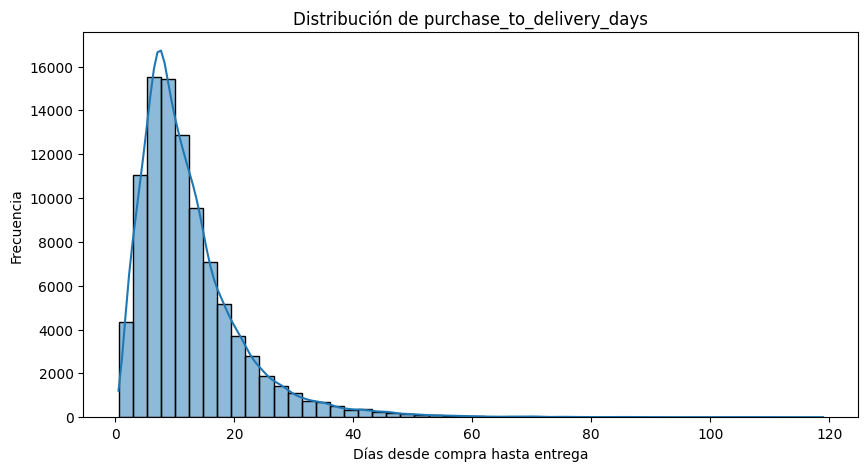

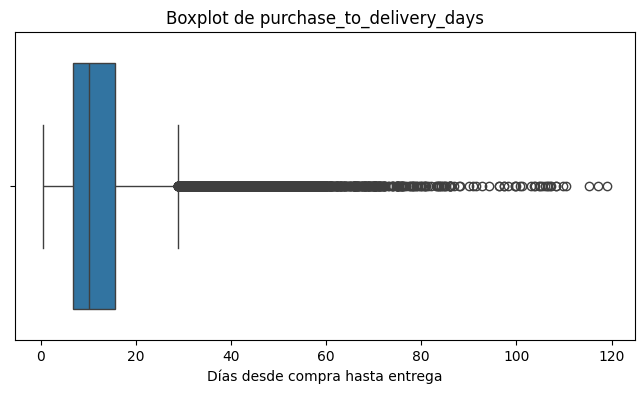


Asimetría purchase_to_delivery_days: 2.356631988159769
Curtosis purchase_to_delivery_days: 10.384677115663983

Comparación entre pedidos tardíos y no tardíos:


,is_late,n_orders,avg_review,bad_review_rate,avg_delivery_days,avg_delay_days,is_late_label
0,0,88163,4.294489,0.092159,10.877733,-13.010581,No tardío
1,1,7620,2.565617,0.540682,30.677802,8.790481,Tardío


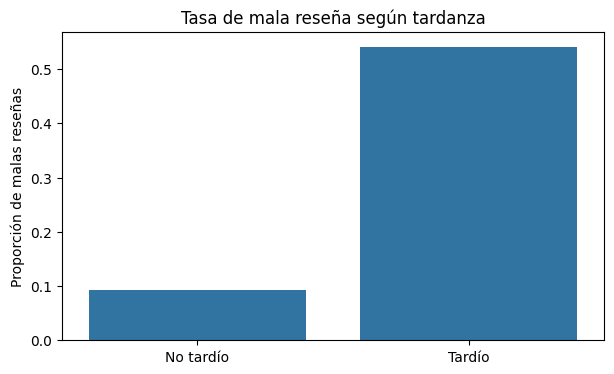

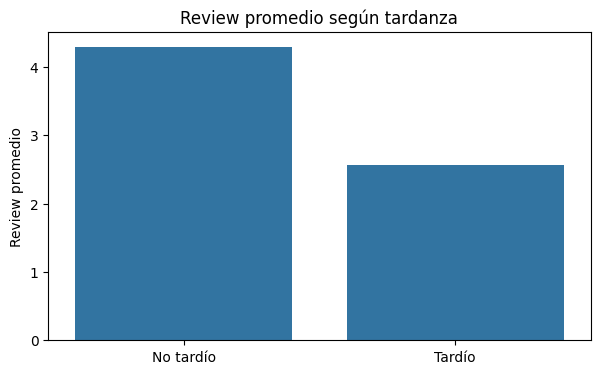


Distribución de score dentro de cada grupo (no tardío / tardío):


is_late,0,1
review_score,,
1,0.065844,0.462205
2,0.026315,0.078478
3,0.079795,0.113517
4,0.203600,0.123097
5,0.624446,0.222703



Resumen por cuartiles de distancia:


/tmp/ipykernel_41103/3397410169.py:136: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_eda.groupby("distance_q")


,distance_q,n_orders,avg_review,bad_review_rate,avg_distance,avg_delivery_days
0,"(-0.001, 184.788]",23514,4.298078,0.097431,64.750936,7.008976
1,"(184.788, 433.814]",23513,4.181049,0.125037,327.027686,11.937136
2,"(433.814, 798.914]",23513,4.136052,0.128865,582.729686,13.640057
3,"(798.914, 8677.912]",23513,4.081912,0.141624,1428.658178,17.364841



Resumen por cuartiles de freight_share:


/tmp/ipykernel_41103/3397410169.py:158: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_eda.groupby("freight_share_q")


,freight_share_q,n_orders,avg_review,bad_review_rate,avg_freight_share
0,"(-0.001, 0.132]",23946,4.201286,0.123110,0.084184
1,"(0.132, 0.224]",23954,4.165275,0.123988,0.175639
2,"(0.224, 0.381]",23938,4.145877,0.130128,0.291929
3,"(0.381, 21.447]",23945,4.115348,0.134141,0.682161


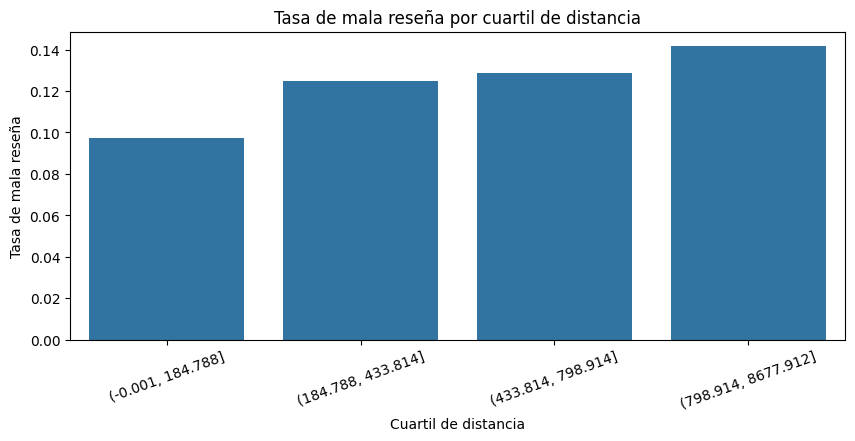

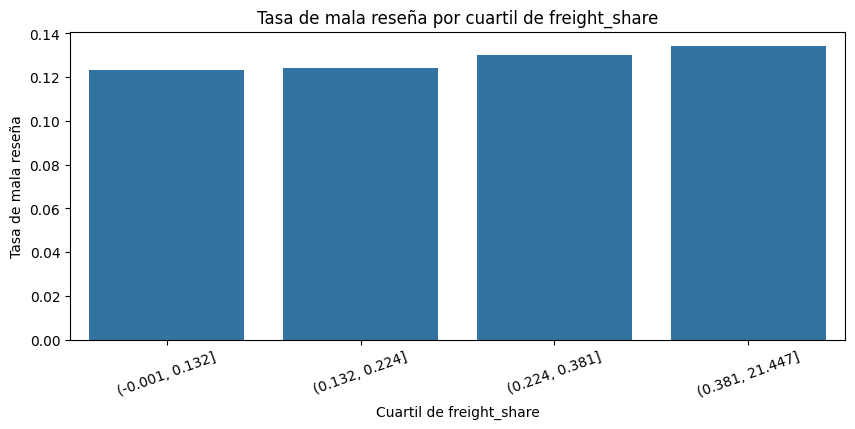


Top 10 categorías por volumen:


,main_category,n_orders,avg_review,bad_review_rate,avg_delivery_days
0,bed_bath_table,9142,4.003610,0.159046,12.908364
1,health_beauty,8574,4.232680,0.113833,12.038051
2,sports_leisure,7430,4.238358,0.111171,12.181584
3,computers_accessories,6486,4.083256,0.144928,13.091748
4,furniture_decor,6158,4.074862,0.149562,12.965505
5,housewares,5635,4.209406,0.114641,11.033274
6,watches_gifts,5410,4.129205,0.134566,12.693256
7,telephony,4045,4.058591,0.139431,12.905661
8,auto,3782,4.148334,0.129297,12.140449
9,toys,3728,4.248659,0.110783,11.678965


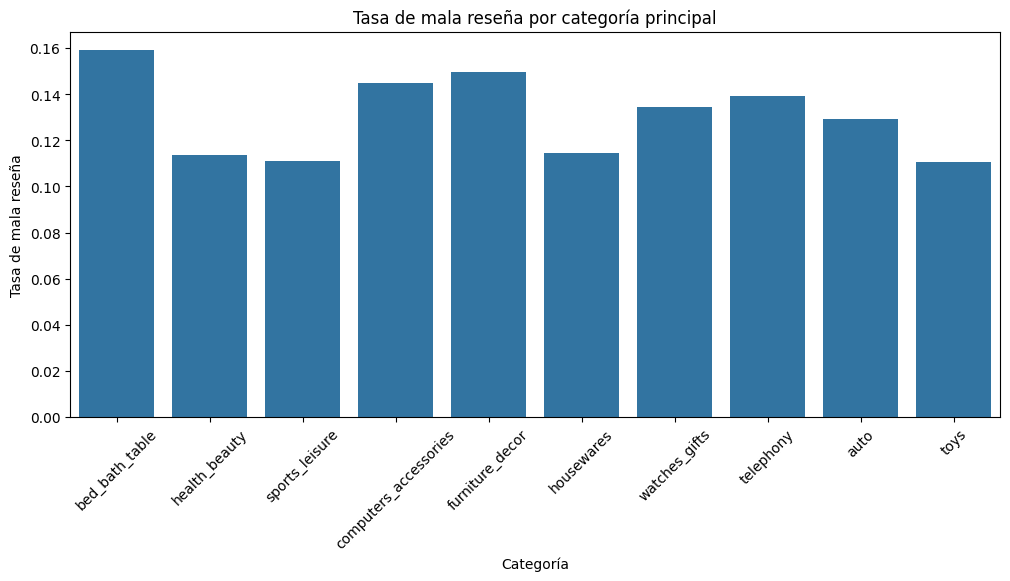

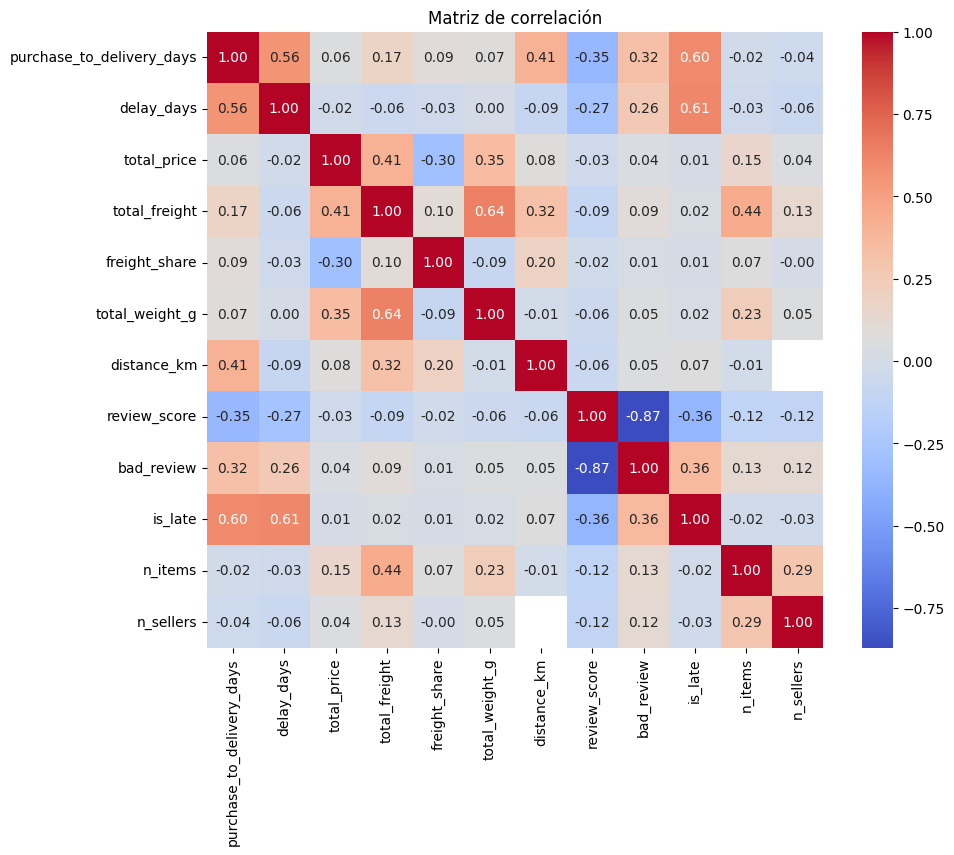


Nulos en variables candidatas para clustering:
distance_km                  1730
purchase_to_delivery_days       0
delay_days                      0
total_price                     0
freight_share                   0
total_weight_g                  0
n_items                         0
dtype: int64

Shape preliminar clustering (antes de dropna): (95783, 7)
Shape clustering si quitamos nulos: (94053, 7)


In [11]:
# ============================================================
# BLOQUE 2 - EDA DIRIGIDO PARA DEFINIR EL ANÁLISIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Trabajamos sobre una copia
df_eda = df_analytic.copy()

# ------------------------------------------------------------
# 1. REVISIÓN GENERAL RÁPIDA
# ------------------------------------------------------------

print("Dimensión:", df_eda.shape)

print("\nResumen de variables clave:")
display(
    df_eda[[
        "purchase_to_delivery_days",
        "delay_days",
        "total_price",
        "total_freight",
        "freight_share",
        "total_weight_g",
        "distance_km",
        "review_score",
        "bad_review",
        "is_late",
        "n_items",
        "n_sellers"
    ]].describe()
)

# ------------------------------------------------------------
# 2. RESEÑAS: distribución y proporción de malas reseñas
# ------------------------------------------------------------

review_dist = (
    df_eda["review_score"]
    .value_counts()
    .sort_index()
    .rename_axis("review_score")
    .reset_index(name="count")
)

review_dist["pct"] = review_dist["count"] / review_dist["count"].sum()

print("\nDistribución de review_score:")
display(review_dist)

bad_review_rate = df_eda["bad_review"].mean()
print(f"\nTasa de mala reseña (score <= 2): {bad_review_rate:.4%}")

# ------------------------------------------------------------
# 3. VARIABLE CANDIDATA PARA MLE
# purchase_to_delivery_days
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_eda["purchase_to_delivery_days"], bins=50, kde=True, ax=ax)
ax.set_title("Distribución de purchase_to_delivery_days")
ax.set_xlabel("Días desde compra hasta entrega")
ax.set_ylabel("Frecuencia")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=df_eda["purchase_to_delivery_days"], ax=ax)
ax.set_title("Boxplot de purchase_to_delivery_days")
ax.set_xlabel("Días desde compra hasta entrega")
plt.show()

print("\nAsimetría purchase_to_delivery_days:", df_eda["purchase_to_delivery_days"].skew())
print("Curtosis purchase_to_delivery_days:", df_eda["purchase_to_delivery_days"].kurt())

# ------------------------------------------------------------
# 4. ENTREGA TARDÍA VS SATISFACCIÓN
# Este bloque será clave para Bayes
# ------------------------------------------------------------

late_vs_review = (
    df_eda.groupby("is_late")
    .agg(
        n_orders=("order_id", "count"),
        avg_review=("review_score", "mean"),
        bad_review_rate=("bad_review", "mean"),
        avg_delivery_days=("purchase_to_delivery_days", "mean"),
        avg_delay_days=("delay_days", "mean")
    )
    .reset_index()
)

late_vs_review["is_late_label"] = late_vs_review["is_late"].map({0: "No tardío", 1: "Tardío"})

print("\nComparación entre pedidos tardíos y no tardíos:")
display(late_vs_review)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=late_vs_review, x="is_late_label", y="bad_review_rate", ax=ax)
ax.set_title("Tasa de mala reseña según tardanza")
ax.set_xlabel("")
ax.set_ylabel("Proporción de malas reseñas")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=late_vs_review, x="is_late_label", y="avg_review", ax=ax)
ax.set_title("Review promedio según tardanza")
ax.set_xlabel("")
ax.set_ylabel("Review promedio")
plt.show()

# Tabla cruzada más detallada
review_by_late = pd.crosstab(
    df_eda["review_score"],
    df_eda["is_late"],
    normalize="columns"
)

print("\nDistribución de score dentro de cada grupo (no tardío / tardío):")
display(review_by_late)

# ------------------------------------------------------------
# 5. DISTANCIA Y FLETE VS SATISFACCIÓN
# ------------------------------------------------------------

# Cuartiles de distancia
df_eda["distance_q"] = pd.qcut(
    df_eda["distance_km"],
    q=4,
    duplicates="drop"
)

distance_summary = (
    df_eda.groupby("distance_q")
    .agg(
        n_orders=("order_id", "count"),
        avg_review=("review_score", "mean"),
        bad_review_rate=("bad_review", "mean"),
        avg_distance=("distance_km", "mean"),
        avg_delivery_days=("purchase_to_delivery_days", "mean")
    )
    .reset_index()
)

print("\nResumen por cuartiles de distancia:")
display(distance_summary)

# Cuartiles de freight_share
df_eda["freight_share_q"] = pd.qcut(
    df_eda["freight_share"],
    q=4,
    duplicates="drop"
)

freight_summary = (
    df_eda.groupby("freight_share_q")
    .agg(
        n_orders=("order_id", "count"),
        avg_review=("review_score", "mean"),
        bad_review_rate=("bad_review", "mean"),
        avg_freight_share=("freight_share", "mean")
    )
    .reset_index()
)

print("\nResumen por cuartiles de freight_share:")
display(freight_summary)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=distance_summary, x="distance_q", y="bad_review_rate", ax=ax)
ax.set_title("Tasa de mala reseña por cuartil de distancia")
ax.set_xlabel("Cuartil de distancia")
ax.set_ylabel("Tasa de mala reseña")
ax.tick_params(axis='x', rotation=20)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=freight_summary, x="freight_share_q", y="bad_review_rate", ax=ax)
ax.set_title("Tasa de mala reseña por cuartil de freight_share")
ax.set_xlabel("Cuartil de freight_share")
ax.set_ylabel("Tasa de mala reseña")
ax.tick_params(axis='x', rotation=20)
plt.show()

# ------------------------------------------------------------
# 6. CATEGORÍA PRINCIPAL VS SATISFACCIÓN
# Solo categorías con volumen razonable
# ------------------------------------------------------------

top_categories = df_eda["main_category"].value_counts().head(10).index

cat_summary = (
    df_eda[df_eda["main_category"].isin(top_categories)]
    .groupby("main_category")
    .agg(
        n_orders=("order_id", "count"),
        avg_review=("review_score", "mean"),
        bad_review_rate=("bad_review", "mean"),
        avg_delivery_days=("purchase_to_delivery_days", "mean")
    )
    .sort_values("n_orders", ascending=False)
    .reset_index()
)

print("\nTop 10 categorías por volumen:")
display(cat_summary)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=cat_summary, x="main_category", y="bad_review_rate", ax=ax)
ax.set_title("Tasa de mala reseña por categoría principal")
ax.set_xlabel("Categoría")
ax.set_ylabel("Tasa de mala reseña")
ax.tick_params(axis='x', rotation=45)
plt.show()

# ------------------------------------------------------------
# 7. MATRIZ DE CORRELACIÓN PARA VARIABLES NUMÉRICAS
# Útil para clustering y para narrativa de negocio
# ------------------------------------------------------------

corr_vars = [
    "purchase_to_delivery_days",
    "delay_days",
    "total_price",
    "total_freight",
    "freight_share",
    "total_weight_g",
    "distance_km",
    "review_score",
    "bad_review",
    "is_late",
    "n_items",
    "n_sellers"
]

corr_matrix = df_eda[corr_vars].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Matriz de correlación")
plt.show()

# ------------------------------------------------------------
# 8. SELECCIÓN PRELIMINAR DE VARIABLES PARA CLUSTERING
# Vamos a crear una base preliminar y revisar nulos
# ------------------------------------------------------------

cluster_vars = [
    "distance_km",
    "purchase_to_delivery_days",
    "delay_days",
    "total_price",
    "freight_share",
    "total_weight_g",
    "n_items"
]

cluster_df = df_eda[cluster_vars].copy()

print("\nNulos en variables candidatas para clustering:")
print(cluster_df.isna().sum())

print("\nShape preliminar clustering (antes de dropna):", cluster_df.shape)
print("Shape clustering si quitamos nulos:", cluster_df.dropna().shape)

En Olist, la experiencia del cliente parece deteriorarse principalmente cuando el pedido llega tarde. La tardanza muestra un efecto mucho más fuerte sobre la reseña que la distancia o el peso relativo del flete. Además, el tiempo total de entrega tiene una distribución claramente asimétrica, por lo que resulta más apropiado modelarlo con distribuciones positivas como Gamma, Lognormal o Weibull, en lugar de asumir normalidad

Número de observaciones para MLE: 95783
Mínimo: 0.5334143518518518
Máximo: 118.96956018518519
Media: 12.452923938722792
Desviación estándar: 8.930344164539443

Resultados MLE ordenados por AIC:


,distribution,params,k_params,log_likelihood,AIC,BIC
0,Lognormal,"(0.6766537168893753, 0, 10.003546056139921)",2,-319080.235103,638164.470206,638183.409887
1,Gamma,"(2.4366450419791033, 0, 5.1106844551343515)",2,-320322.030734,640648.061468,640667.001149
2,Weibull,"(1.5384785422316223, 0, 13.93639510281648)",2,-323962.301857,647928.603713,647947.543394
3,Exponential,"(0.0, 12.452923938722792)",1,-337343.458853,674688.917706,674698.387547
4,Normal,"(12.452923938722792, 8.93029754683339)",2,-345622.251506,691248.503011,691267.442692



Mejor modelo por AIC: Lognormal
AIC mejor modelo: 638164.47
Segundo mejor modelo: Gamma
AIC segundo modelo: 640648.06
Diferencia AIC: 2483.59

Mejor modelo por BIC: Lognormal
Diferencia BIC entre mejor y segundo: 2483.59

Tabla resumida:


,distribution,params_readable,log_likelihood,AIC,BIC
0,Lognormal,"shape=0.6767, loc=0.0000, scale=10.0035",-319080.235103,638164.470206,638183.409887
1,Gamma,"shape=2.4366, loc=0.0000, scale=5.1107",-320322.030734,640648.061468,640667.001149
2,Weibull,"shape=1.5385, loc=0.0000, scale=13.9364",-323962.301857,647928.603713,647947.543394
3,Exponential,"loc=0.0000, scale=12.4529, lambda=0.0803",-337343.458853,674688.917706,674698.387547
4,Normal,"mu=12.4529, sigma=8.9303",-345622.251506,691248.503011,691267.442692


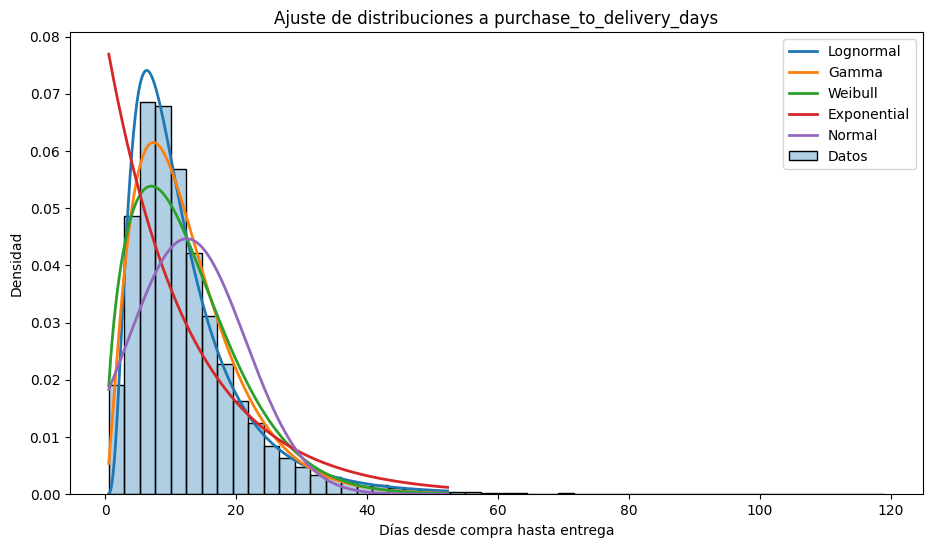

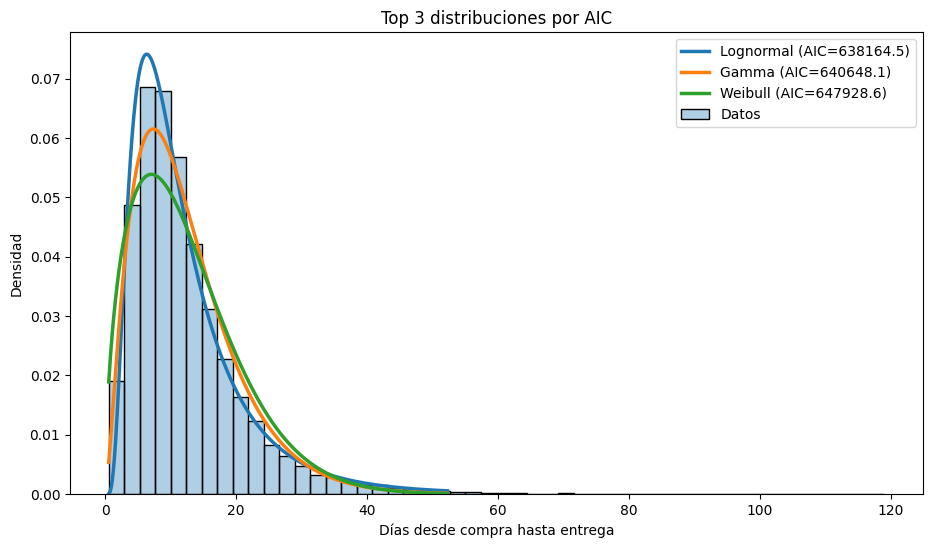


 RESUMEN PARA DEFENSA
Variable analizada: purchase_to_delivery_days
Mejor distribución por AIC: Lognormal
AIC mejor modelo: 638164.47
AIC segundo modelo: 640648.06
Diferencia AIC: 2483.59
BIC mejor modelo: 638183.41
Parámetros del mejor modelo: shape=0.6767, loc=0.0000, scale=10.0035


In [12]:
# ============================================================
# BLOQUE 3 - MLE Y SELECCIÓN DE MODELO CON AIC/BIC
# Variable principal: purchase_to_delivery_days
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ------------------------------------------------------------
# 1. VARIABLE DE TRABAJO
# ------------------------------------------------------------

x = df_analytic["purchase_to_delivery_days"].dropna().copy()

# Por seguridad, dejamos solo valores positivos
x = x[x > 0].copy()

print("Número de observaciones para MLE:", len(x))
print("Mínimo:", x.min())
print("Máximo:", x.max())
print("Media:", x.mean())
print("Desviación estándar:", x.std())

# ------------------------------------------------------------
# 2. AJUSTE DE DISTRIBUCIONES CANDIDATAS
# Incluimos Normal como benchmark, aunque sabemos que no es
# la más natural para esta variable.
# Para las distribuciones positivas fijamos loc = 0.
# ------------------------------------------------------------

results = []

candidate_distributions = {
    "Normal": {
        "dist": stats.norm,
        "fit_kwargs": {},
        "k": 2
    },
    "Exponential": {
        "dist": stats.expon,
        "fit_kwargs": {"floc": 0},
        "k": 1  # scale
    },
    "Gamma": {
        "dist": stats.gamma,
        "fit_kwargs": {"floc": 0},
        "k": 2  # shape, scale
    },
    "Lognormal": {
        "dist": stats.lognorm,
        "fit_kwargs": {"floc": 0},
        "k": 2  # shape, scale
    },
    "Weibull": {
        "dist": stats.weibull_min,
        "fit_kwargs": {"floc": 0},
        "k": 2  # shape, scale
    }
}

for name, config in candidate_distributions.items():
    dist = config["dist"]
    fit_kwargs = config["fit_kwargs"]
    k = config["k"]

    try:
        params = dist.fit(x, **fit_kwargs)

        # log-verosimilitud
        logpdf_vals = dist.logpdf(x, *params)
        ll = np.sum(logpdf_vals)

        n = len(x)
        aic = 2 * k - 2 * ll
        bic = np.log(n) * k - 2 * ll

        results.append({
            "distribution": name,
            "params": params,
            "k_params": k,
            "log_likelihood": ll,
            "AIC": aic,
            "BIC": bic
        })

    except Exception as e:
        results.append({
            "distribution": name,
            "params": str(e),
            "k_params": k,
            "log_likelihood": np.nan,
            "AIC": np.nan,
            "BIC": np.nan
        })

mle_results = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)

print("\nResultados MLE ordenados por AIC:")
display(mle_results)

# ------------------------------------------------------------
# 3. DIFERENCIA ENTRE EL MEJOR Y EL SEGUNDO MODELO
# Esto te sirve directo para la defensa oral.
# ------------------------------------------------------------

best_model = mle_results.iloc[0].copy()
second_model = mle_results.iloc[1].copy()

delta_aic = second_model["AIC"] - best_model["AIC"]
delta_bic = second_model["BIC"] - best_model["BIC"]

print("\nMejor modelo por AIC:", best_model["distribution"])
print("AIC mejor modelo:", round(best_model["AIC"], 2))
print("Segundo mejor modelo:", second_model["distribution"])
print("AIC segundo modelo:", round(second_model["AIC"], 2))
print("Diferencia AIC:", round(delta_aic, 2))

print("\nMejor modelo por BIC:", mle_results.sort_values("BIC").iloc[0]["distribution"])
print("Diferencia BIC entre mejor y segundo:", round(delta_bic, 2))

# ------------------------------------------------------------
# 4. INTERPRETACIÓN DE PARÁMETROS
# Dejamos una tabla legible según la distribución
# ------------------------------------------------------------

def format_params(row):
    name = row["distribution"]
    params = row["params"]

    if not isinstance(params, tuple):
        return str(params)

    if name == "Normal":
        mu, sigma = params
        return f"mu={mu:.4f}, sigma={sigma:.4f}"

    elif name == "Exponential":
        loc, scale = params
        return f"loc={loc:.4f}, scale={scale:.4f}, lambda={1/scale:.4f}"

    elif name == "Gamma":
        shape, loc, scale = params
        return f"shape={shape:.4f}, loc={loc:.4f}, scale={scale:.4f}"

    elif name == "Lognormal":
        shape, loc, scale = params
        return f"shape={shape:.4f}, loc={loc:.4f}, scale={scale:.4f}"

    elif name == "Weibull":
        c, loc, scale = params
        return f"shape={c:.4f}, loc={loc:.4f}, scale={scale:.4f}"

    return str(params)

mle_results["params_readable"] = mle_results.apply(format_params, axis=1)

print("\nTabla resumida:")
display(mle_results[["distribution", "params_readable", "log_likelihood", "AIC", "BIC"]])

# ------------------------------------------------------------
# 5. GRÁFICA: HISTOGRAMA + CURVAS AJUSTADAS
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))
sns.histplot(x, bins=50, stat="density", kde=False, alpha=0.35, label="Datos")

x_grid = np.linspace(x.min(), x.quantile(0.995), 600)

for _, row in mle_results.iterrows():
    name = row["distribution"]
    params = row["params"]

    if not isinstance(params, tuple):
        continue

    if name == "Normal":
        y = stats.norm.pdf(x_grid, *params)
    elif name == "Exponential":
        y = stats.expon.pdf(x_grid, *params)
    elif name == "Gamma":
        y = stats.gamma.pdf(x_grid, *params)
    elif name == "Lognormal":
        y = stats.lognorm.pdf(x_grid, *params)
    elif name == "Weibull":
        y = stats.weibull_min.pdf(x_grid, *params)
    else:
        continue

    plt.plot(x_grid, y, linewidth=2, label=name)

plt.title("Ajuste de distribuciones a purchase_to_delivery_days")
plt.xlabel("Días desde compra hasta entrega")
plt.ylabel("Densidad")
plt.legend()
plt.show()

# ------------------------------------------------------------
# 6. GRÁFICA SOLO TOP 3 MODELOS
# Para una visual más limpia en el informe/video
# ------------------------------------------------------------

top3 = mle_results.head(3).copy()

plt.figure(figsize=(11, 6))
sns.histplot(x, bins=50, stat="density", kde=False, alpha=0.35, label="Datos")

for _, row in top3.iterrows():
    name = row["distribution"]
    params = row["params"]

    if name == "Normal":
        y = stats.norm.pdf(x_grid, *params)
    elif name == "Exponential":
        y = stats.expon.pdf(x_grid, *params)
    elif name == "Gamma":
        y = stats.gamma.pdf(x_grid, *params)
    elif name == "Lognormal":
        y = stats.lognorm.pdf(x_grid, *params)
    elif name == "Weibull":
        y = stats.weibull_min.pdf(x_grid, *params)
    else:
        continue

    plt.plot(x_grid, y, linewidth=2.5, label=f"{name} (AIC={row['AIC']:.1f})")

plt.title("Top 3 distribuciones por AIC")
plt.xlabel("Días desde compra hasta entrega")
plt.ylabel("Densidad")
plt.legend()
plt.show()

# ------------------------------------------------------------
# 7. INSUMOS DE DEFENSA ORAL
# ------------------------------------------------------------

print("\n RESUMEN PARA DEFENSA")
print(f"Variable analizada: purchase_to_delivery_days")
print(f"Mejor distribución por AIC: {best_model['distribution']}")
print(f"AIC mejor modelo: {best_model['AIC']:.2f}")
print(f"AIC segundo modelo: {second_model['AIC']:.2f}")
print(f"Diferencia AIC: {delta_aic:.2f}")
print(f"BIC mejor modelo: {mle_results.sort_values('BIC').iloc[0]['BIC']:.2f}")
print("Parámetros del mejor modelo:", format_params(best_model))

# Inferencia bayesiana

Pedidos tardíos totales: 7620

Resumen de pedidos tardíos por año:


,purchase_year,n_late_orders,bad_reviews,bad_review_rate,avg_review
0,2016,3,2,0.666667,2.000000
1,2017,2773,1519,0.547782,2.544897
2,2018,4844,2599,0.536540,2.577828



Histórico (2016-2017)
n_hist: 2776
k_hist: 1521
p_hist: 0.547911

Actual (2018)
n_curr: 4844
k_curr: 2599
p_curr_mle: 0.53654

Prior informado Beta(alpha, beta)
alpha_prior: 109.5821
beta_prior: 90.4179
media prior: 0.547911

Posterior informado
alpha_post: 2708.5821
beta_post: 2335.4179
media posterior: 0.536991
IC creíble 95%: [np.float64(0.523218), np.float64(0.550736)]

Posterior con prior no informativo Beta(1,1)
media posterior no informativo: 0.536525
IC creíble 95% no informativo: [np.float64(0.522473), np.float64(0.550549)]

Resumen bayesiano:


,metric,value
0,Probabilidad histórica (2016-2017),0.547911
1,MLE actual 2018,0.536540
2,Media prior informada,0.547911
3,Media posterior informada,0.536991
4,Límite inferior IC 95%,0.523218
5,Límite superior IC 95%,0.550736
6,"Media posterior con Beta(1,1)",0.536525


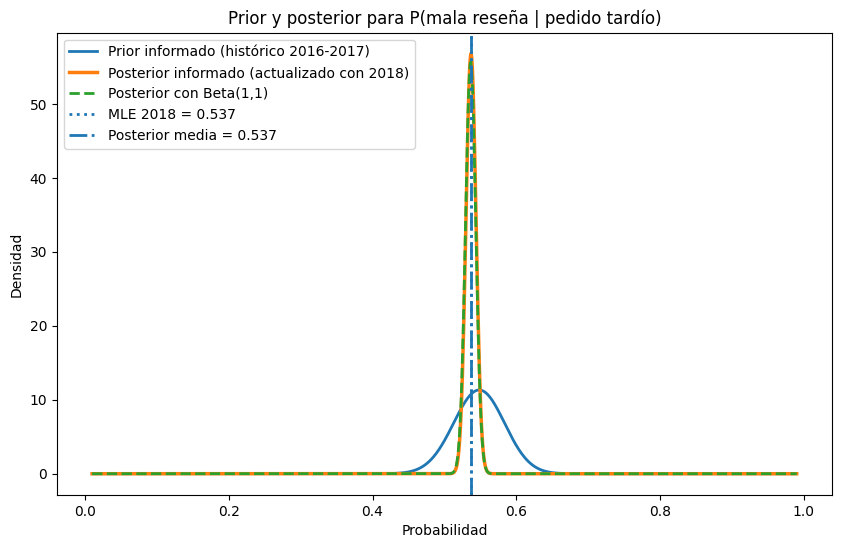


 RESUMEN
Parámetro modelado: theta = P(mala reseña | pedido tardío)
Tasa histórica (2016-2017): 54.7911%
MLE actual en 2018: 53.6540%
Media posterior informada: 53.6991%
Intervalo de credibilidad 95%: [52.3218%, 55.0736%]
Posterior con prior no informativo Beta(1,1): 53.6525%
Diferencia entre posterior informado y no informativo: 0.000466


In [13]:
# ============================================================
# BLOQUE 4 - INFERENCIA BAYESIANA
# Theta = P(bad_review = 1 | is_late = 1)
# Prior histórico: 2016-2017
# Evidencia nueva: 2018
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta

# ------------------------------------------------------------
# 1. PREPARACIÓN
# ------------------------------------------------------------

df_bayes = df_analytic.copy()
df_bayes["purchase_year"] = df_bayes["order_purchase_timestamp"].dt.year

# Nos quedamos solo con pedidos tardíos
late_df = df_bayes[df_bayes["is_late"] == 1].copy()

print("Pedidos tardíos totales:", late_df.shape[0])

# Revisión por año
year_summary = (
    late_df.groupby("purchase_year")
    .agg(
        n_late_orders=("order_id", "count"),
        bad_reviews=("bad_review", "sum"),
        bad_review_rate=("bad_review", "mean"),
        avg_review=("review_score", "mean")
    )
    .reset_index()
)

print("\nResumen de pedidos tardíos por año:")
display(year_summary)

# ------------------------------------------------------------
# 2. DEFINICIÓN DE PRIOR HISTÓRICO Y EVIDENCIA ACTUAL
# Histórico: 2016-2017
# Actual: 2018
# ------------------------------------------------------------

historical = late_df[late_df["purchase_year"].isin([2016, 2017])].copy()
current = late_df[late_df["purchase_year"] == 2018].copy()

n_hist = historical.shape[0]
k_hist = historical["bad_review"].sum()
p_hist = historical["bad_review"].mean()

n_curr = current.shape[0]
k_curr = current["bad_review"].sum()
p_curr_mle = current["bad_review"].mean()

print("\nHistórico (2016-2017)")
print("n_hist:", n_hist)
print("k_hist:", k_hist)
print("p_hist:", round(p_hist, 6))

print("\nActual (2018)")
print("n_curr:", n_curr)
print("k_curr:", k_curr)
print("p_curr_mle:", round(p_curr_mle, 6))

# ------------------------------------------------------------
# 3. CONSTRUCCIÓN DEL PRIOR BETA INFORMADO
# Usamos la tasa histórica como media del prior y una fuerza
# moderada de 200 pseudo-observaciones
# ------------------------------------------------------------

prior_strength = 200

alpha_prior = p_hist * prior_strength
beta_prior = (1 - p_hist) * prior_strength

print("\nPrior informado Beta(alpha, beta)")
print("alpha_prior:", round(alpha_prior, 4))
print("beta_prior:", round(beta_prior, 4))
print("media prior:", round(alpha_prior / (alpha_prior + beta_prior), 6))

# ------------------------------------------------------------
# 4. POSTERIOR
# ------------------------------------------------------------

alpha_post = alpha_prior + k_curr
beta_post = beta_prior + (n_curr - k_curr)

posterior_mean = alpha_post / (alpha_post + beta_post)
posterior_ci_95 = beta.ppf([0.025, 0.975], alpha_post, beta_post)

print("\nPosterior informado")
print("alpha_post:", round(alpha_post, 4))
print("beta_post:", round(beta_post, 4))
print("media posterior:", round(posterior_mean, 6))
print("IC creíble 95%:", [round(x, 6) for x in posterior_ci_95])

# ------------------------------------------------------------
# 5. COMPARACIÓN CON PRIOR NO INFORMATIVO Beta(1,1)
# Esto te sirve para la defensa si te preguntan qué cambiaría
# ------------------------------------------------------------

alpha_post_unif = 1 + k_curr
beta_post_unif = 1 + (n_curr - k_curr)

posterior_mean_unif = alpha_post_unif / (alpha_post_unif + beta_post_unif)
posterior_ci_95_unif = beta.ppf([0.025, 0.975], alpha_post_unif, beta_post_unif)

print("\nPosterior con prior no informativo Beta(1,1)")
print("media posterior no informativo:", round(posterior_mean_unif, 6))
print("IC creíble 95% no informativo:", [round(x, 6) for x in posterior_ci_95_unif])

# ------------------------------------------------------------
# 6. TABLA RESUMEN
# ------------------------------------------------------------

bayes_summary = pd.DataFrame({
    "metric": [
        "Probabilidad histórica (2016-2017)",
        "MLE actual 2018",
        "Media prior informada",
        "Media posterior informada",
        "Límite inferior IC 95%",
        "Límite superior IC 95%",
        "Media posterior con Beta(1,1)"
    ],
    "value": [
        p_hist,
        p_curr_mle,
        alpha_prior / (alpha_prior + beta_prior),
        posterior_mean,
        posterior_ci_95[0],
        posterior_ci_95[1],
        posterior_mean_unif
    ]
})

print("\nResumen bayesiano:")
display(bayes_summary)

# ------------------------------------------------------------
# 7. GRÁFICA PRIOR VS POSTERIOR
# ------------------------------------------------------------

x_grid = np.linspace(0.01, 0.99, 1000)

prior_pdf = beta.pdf(x_grid, alpha_prior, beta_prior)
post_pdf = beta.pdf(x_grid, alpha_post, beta_post)
post_unif_pdf = beta.pdf(x_grid, alpha_post_unif, beta_post_unif)

plt.figure(figsize=(10, 6))
plt.plot(x_grid, prior_pdf, label="Prior informado (histórico 2016-2017)", linewidth=2)
plt.plot(x_grid, post_pdf, label="Posterior informado (actualizado con 2018)", linewidth=2.5)
plt.plot(x_grid, post_unif_pdf, label="Posterior con Beta(1,1)", linewidth=2, linestyle="--")

plt.axvline(p_curr_mle, linestyle=":", linewidth=2, label=f"MLE 2018 = {p_curr_mle:.3f}")
plt.axvline(posterior_mean, linestyle="-.", linewidth=2, label=f"Posterior media = {posterior_mean:.3f}")

plt.title("Prior y posterior para P(mala reseña | pedido tardío)")
plt.xlabel("Probabilidad")
plt.ylabel("Densidad")
plt.legend()
plt.show()

# ------------------------------------------------------------
# 8. INTERPRETACIÓN LISTA PARA DEFENSA
# ------------------------------------------------------------

print("\n RESUMEN")
print("Parámetro modelado: theta = P(mala reseña | pedido tardío)")
print(f"Tasa histórica (2016-2017): {p_hist:.4%}")
print(f"MLE actual en 2018: {p_curr_mle:.4%}")
print(f"Media posterior informada: {posterior_mean:.4%}")
print(f"Intervalo de credibilidad 95%: [{posterior_ci_95[0]:.4%}, {posterior_ci_95[1]:.4%}]")
print(f"Posterior con prior no informativo Beta(1,1): {posterior_mean_unif:.4%}")
print(f"Diferencia entre posterior informado y no informativo: {(posterior_mean - posterior_mean_unif):.6f}")

# Montecarlo

Número de simulaciones: 10000
Pedidos tardíos base en 2018: 4844
Posterior mean theta: 0.5369909065354563

Resumen Monte Carlo:


,reduction_pct,late_orders_after_reduction,expected_bad_reviews_baseline,expected_bad_reviews_new,expected_bad_reviews_avoided,median_avoided,p05_avoided,p95_avoided,relative_reduction_in_bad_reviews
0,0.1,4360,2600.8659,2340.8486,260.0173,259.0,182.0,340.0,0.099973
1,0.2,3875,2600.8659,2080.6755,520.1904,520.0,443.0,597.0,0.200007
2,0.3,3391,2600.8659,1820.9664,779.8995,779.0,705.0,857.0,0.299861
3,0.4,2906,2600.8659,1560.4488,1040.4171,1041.0,965.0,1115.0,0.400027


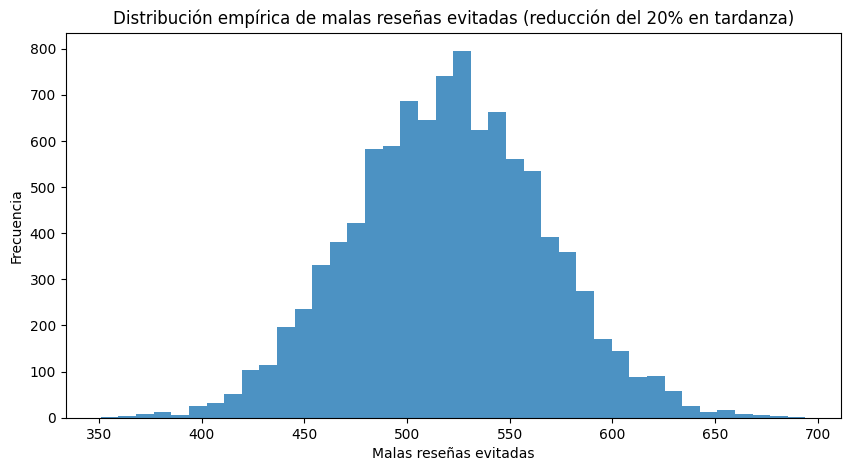

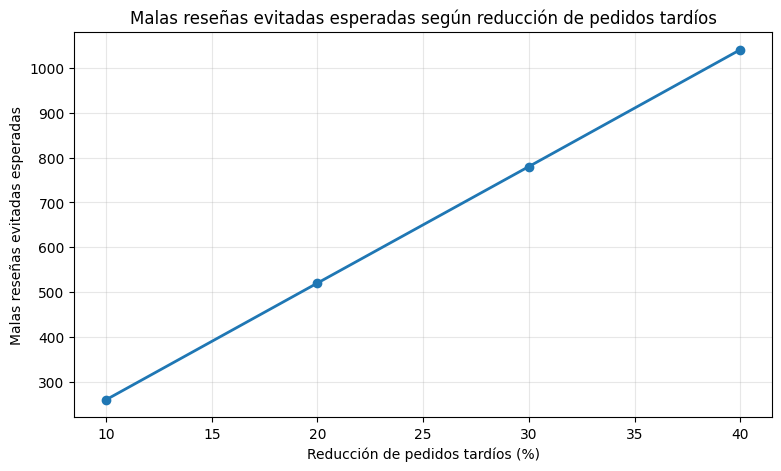

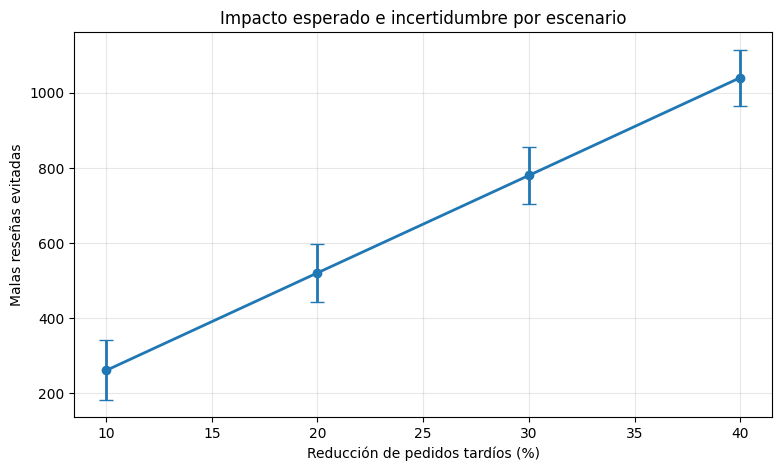

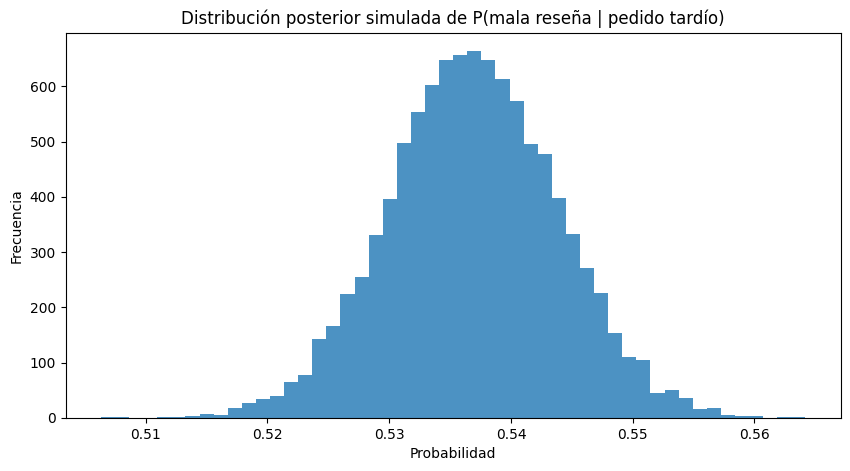


 RESUMEN 
Escenario base: 4844 pedidos tardíos en 2018
Posterior media de P(mala reseña | tardío): 53.6991%
Escenario principal: reducción del 20% de pedidos tardíos
Malas reseñas esperadas en escenario base: 2600.87
Malas reseñas esperadas con mejora: 2080.68
Malas reseñas evitadas esperadas: 520.19
Intervalo empírico 90%: [443.00, 597.00]
Reducción relativa de malas reseñas: 20.00%


In [14]:
# ============================================================
# BLOQUE 5 - SIMULACIÓN MONTE CARLO
# Impacto esperado de reducir pedidos tardíos en 2018
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. PARÁMETROS DE ENTRADA
# Usamos el posterior del bloque bayesiano
# ------------------------------------------------------------

N = 10000  # número de simulaciones
n_late_2018 = n_curr  # pedidos tardíos observados en 2018

reduction_scenarios = [0.10, 0.20, 0.30, 0.40]

print("Número de simulaciones:", N)
print("Pedidos tardíos base en 2018:", n_late_2018)
print("Posterior mean theta:", posterior_mean)

# ------------------------------------------------------------
# 2. SIMULACIÓN BASELINE
# theta ~ posterior Beta(alpha_post, beta_post)
# bad_reviews_baseline ~ Binomial(n_late_2018, theta)
# ------------------------------------------------------------

theta_samples = np.random.beta(alpha_post, beta_post, size=N)
bad_reviews_baseline = np.random.binomial(n=n_late_2018, p=theta_samples, size=N)

# ------------------------------------------------------------
# 3. SIMULACIÓN DE ESCENARIOS
# ------------------------------------------------------------

scenario_results = []

sim_distributions = {}

for r in reduction_scenarios:
    n_late_new = int(round(n_late_2018 * (1 - r)))

    bad_reviews_new = np.random.binomial(n=n_late_new, p=theta_samples, size=N)
    avoided_bad_reviews = bad_reviews_baseline - bad_reviews_new

    sim_distributions[r] = avoided_bad_reviews

    scenario_results.append({
        "reduction_pct": r,
        "late_orders_after_reduction": n_late_new,
        "expected_bad_reviews_baseline": bad_reviews_baseline.mean(),
        "expected_bad_reviews_new": bad_reviews_new.mean(),
        "expected_bad_reviews_avoided": avoided_bad_reviews.mean(),
        "median_avoided": np.median(avoided_bad_reviews),
        "p05_avoided": np.percentile(avoided_bad_reviews, 5),
        "p95_avoided": np.percentile(avoided_bad_reviews, 95),
        "relative_reduction_in_bad_reviews": avoided_bad_reviews.mean() / bad_reviews_baseline.mean()
    })

mc_summary = pd.DataFrame(scenario_results)

print("\nResumen Monte Carlo:")
display(mc_summary)

# ------------------------------------------------------------
# 4. HISTOGRAMA DEL ESCENARIO PRINCIPAL
# Elegimos 20% como escenario central de negocio
# ------------------------------------------------------------

main_r = 0.20
main_avoided = sim_distributions[main_r]

plt.figure(figsize=(10, 5))
plt.hist(main_avoided, bins=40, alpha=0.8)
plt.title("Distribución empírica de malas reseñas evitadas (reducción del 20% en tardanza)")
plt.xlabel("Malas reseñas evitadas")
plt.ylabel("Frecuencia")
plt.show()

# ------------------------------------------------------------
# 5. COMPARACIÓN DE ESCENARIOS
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))
plt.plot(
    mc_summary["reduction_pct"] * 100,
    mc_summary["expected_bad_reviews_avoided"],
    marker="o",
    linewidth=2
)
plt.title("Malas reseñas evitadas esperadas según reducción de pedidos tardíos")
plt.xlabel("Reducción de pedidos tardíos (%)")
plt.ylabel("Malas reseñas evitadas esperadas")
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 6. INTERVALOS DE INCERTIDUMBRE
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))
x = mc_summary["reduction_pct"] * 100
y = mc_summary["expected_bad_reviews_avoided"]
yerr_lower = y - mc_summary["p05_avoided"]
yerr_upper = mc_summary["p95_avoided"] - y

plt.errorbar(
    x,
    y,
    yerr=[yerr_lower, yerr_upper],
    fmt="o-",
    capsize=5,
    linewidth=2
)

plt.title("Impacto esperado e incertidumbre por escenario")
plt.xlabel("Reducción de pedidos tardíos (%)")
plt.ylabel("Malas reseñas evitadas")
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 7. PORCENTAJE DE PEDIDOS TARDÍOS QUE GENERAN MALA RESEÑA
# SEGÚN LA POSTERIOR
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.hist(theta_samples, bins=50, alpha=0.8)
plt.title("Distribución posterior simulada de P(mala reseña | pedido tardío)")
plt.xlabel("Probabilidad")
plt.ylabel("Frecuencia")
plt.show()

# ------------------------------------------------------------
# 8. RESUMEN LISTO PARA DEFENSA
# ------------------------------------------------------------

main_row = mc_summary[mc_summary["reduction_pct"] == main_r].iloc[0]

print("\n RESUMEN ")
print(f"Escenario base: {n_late_2018} pedidos tardíos en 2018")
print(f"Posterior media de P(mala reseña | tardío): {posterior_mean:.4%}")
print(f"Escenario principal: reducción del {int(main_r*100)}% de pedidos tardíos")

print(f"Malas reseñas esperadas en escenario base: {main_row['expected_bad_reviews_baseline']:.2f}")
print(f"Malas reseñas esperadas con mejora: {main_row['expected_bad_reviews_new']:.2f}")
print(f"Malas reseñas evitadas esperadas: {main_row['expected_bad_reviews_avoided']:.2f}")
print(f"Intervalo empírico 90%: [{main_row['p05_avoided']:.2f}, {main_row['p95_avoided']:.2f}]")
print(f"Reducción relativa de malas reseñas: {main_row['relative_reduction_in_bad_reviews']:.2%}")

# Clustering

Usando df_analytic
Shape base clustering: (94053, 12)
Shape matriz escalada: (94053, 7)
Shape muestra evaluación: (30000, 7)

Resultados de validación:


,method,k,silhouette,davies_bouldin,calinski_harabasz,inertia
2,KMeans,4,0.232991,1.338717,7064.250488,122882.593750
3,KMeans,5,0.224319,1.317549,7015.529297,108342.078125
1,KMeans,3,0.207518,1.514366,6763.223633,144529.921875
4,KMeans,6,0.197385,1.365125,6732.263184,98811.164062
0,KMeans,2,0.191903,1.832702,6940.439453,170299.593750


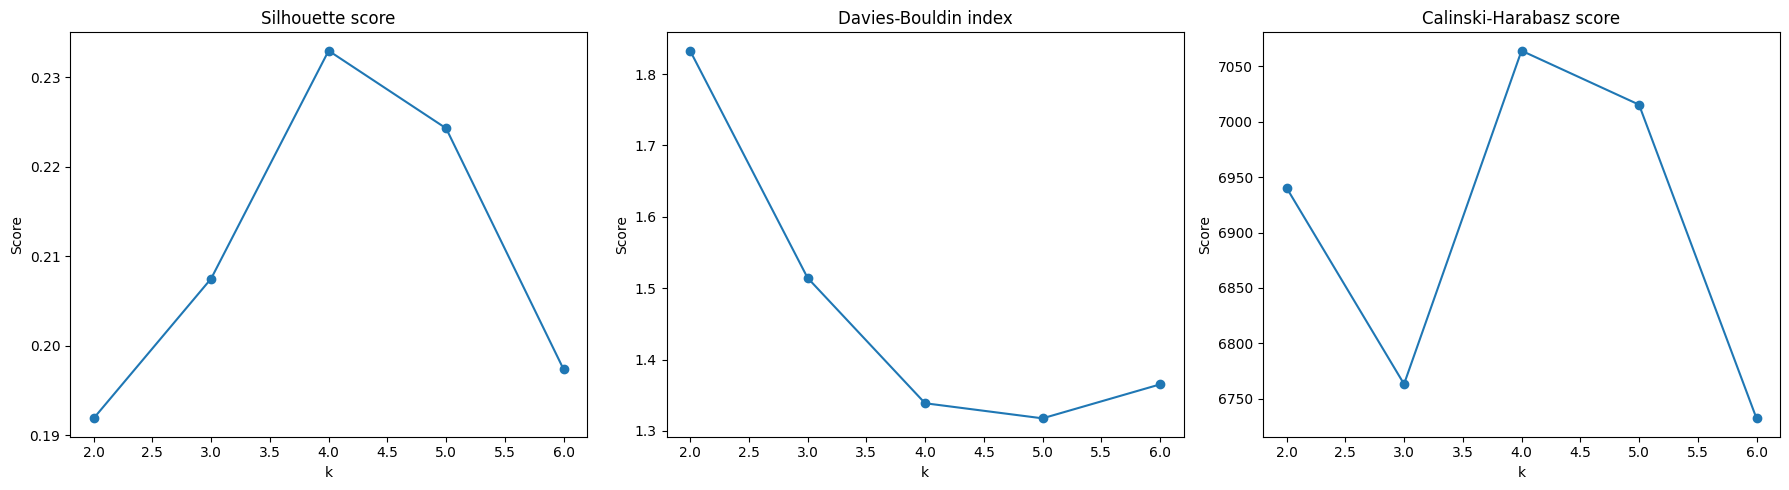


Mejor configuración seleccionada:
method                     KMeans
k                               4
silhouette               0.232991
davies_bouldin           1.338717
calinski_harabasz     7064.250488
inertia              122882.59375
Name: 2, dtype: object

Perfil de clústeres:


,cluster,n_orders,avg_distance_km,avg_delivery_days,avg_delay_days,avg_total_price,avg_freight_share,avg_weight_g,avg_n_items,avg_review,bad_review_rate,late_rate,pct_orders
3,3,7476,583.855780,12.410493,-12.104005,216.821053,0.335654,5407.439139,2.462012,3.738764,0.239433,0.071027,0.079487
0,0,29010,818.592261,15.609778,-10.313086,44.797658,0.547646,625.001655,1.009824,4.091796,0.138159,0.118821,0.308443
1,1,40313,676.392748,13.373803,-12.385242,211.273798,0.165506,3567.524893,1.000000,4.221194,0.110882,0.072136,0.428620
2,2,17254,65.261978,5.201487,-9.618474,77.424729,0.228372,1093.650748,1.026892,4.392025,0.076678,0.038658,0.183450



Top categorías por clúster:


,cluster,main_category,count
43,0,health_beauty,2697
15,0,computers_accessories,2529
7,0,bed_bath_table,2413
77,1,bed_bath_table,4362
134,1,sports_leisure,3350
110,1,health_beauty,3283
183,2,health_beauty,2008
205,2,sports_leisure,1310
189,2,housewares,1226
249,3,furniture_decor,1038


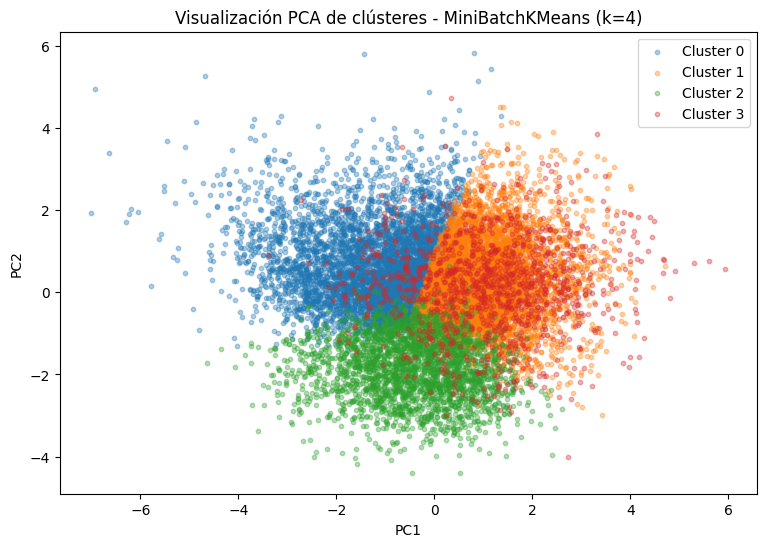

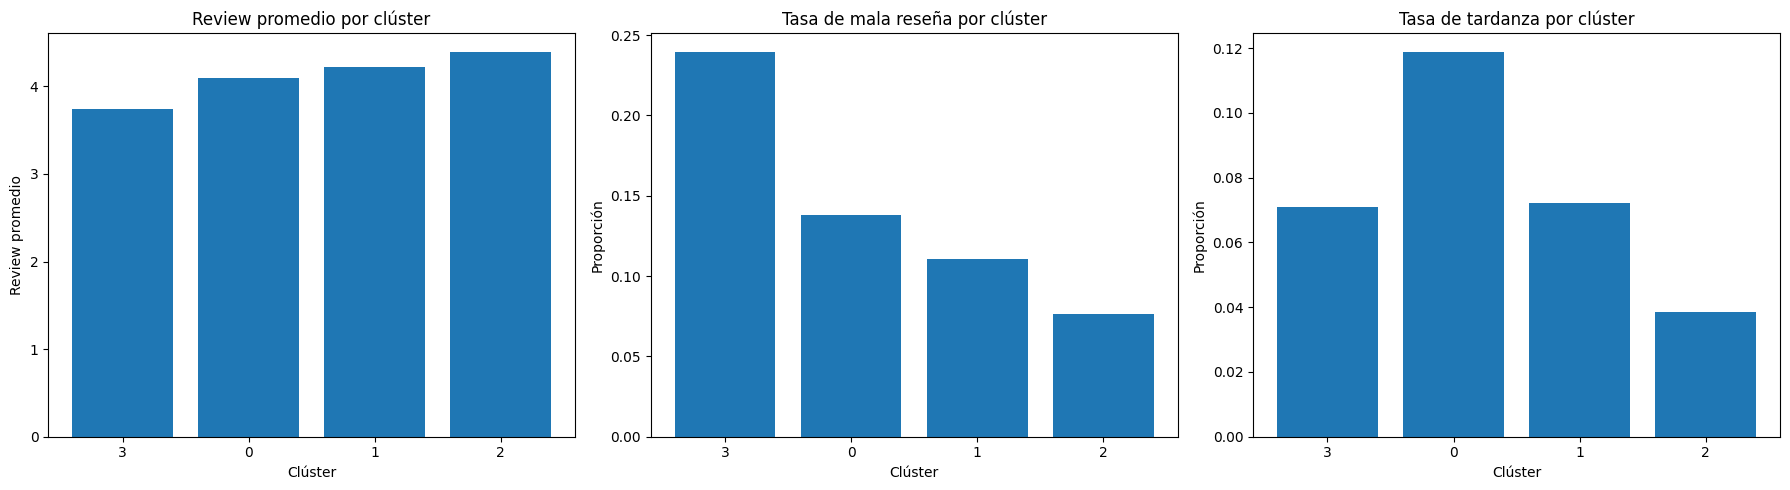


 RESUMEN 
Método final: MiniBatchKMeans
Número óptimo de clústeres: 4
Silhouette (muestra): 0.2330
Davies-Bouldin (muestra): 1.3387
Calinski-Harabasz (muestra): 7064.25
Revisa: cluster_eval, best_row, cluster_profile, top_cat_by_cluster


In [15]:
# ============================================================
# BLOQUE 6 - CLUSTERING LIGERO Y SEGURO (SOLO KMEANS)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# 1. DETECTAR DATAFRAME EN MEMORIA
# ------------------------------------------------------------

if 'df_analytic' in globals():
    cluster_source = df_analytic.copy()
    print("Usando df_analytic")
elif 'df_eda' in globals():
    cluster_source = df_eda.copy()
    print("Usando df_eda")
elif 'df' in globals():
    cluster_source = df.copy()
    print("Usando df")
else:
    raise NameError(
        "No encuentro df_analytic, df_eda ni df en memoria. "
        "Debes volver a correr el bloque del dataset maestro."
    )

# ------------------------------------------------------------
# 2. BASE DEL CLUSTERING
# ------------------------------------------------------------

cluster_vars = [
    "distance_km",
    "purchase_to_delivery_days",
    "delay_days",
    "total_price",
    "freight_share",
    "total_weight_g",
    "n_items"
]

required_cols = [
    "order_id",
    "review_score",
    "bad_review",
    "is_late",
    "main_category"
] + cluster_vars

cluster_base = cluster_source[required_cols].dropna(subset=cluster_vars).copy()

print("Shape base clustering:", cluster_base.shape)

# ------------------------------------------------------------
# 3. TRANSFORMACIONES
# ------------------------------------------------------------

cluster_work = cluster_base.copy()

log_vars = [
    "distance_km",
    "purchase_to_delivery_days",
    "total_price",
    "freight_share",
    "total_weight_g",
    "n_items"
]

for col in log_vars:
    cluster_work[f"log_{col}"] = np.log1p(cluster_work[col])

model_vars = [
    "log_distance_km",
    "log_purchase_to_delivery_days",
    "delay_days",
    "log_total_price",
    "log_freight_share",
    "log_total_weight_g",
    "log_n_items"
]

X = cluster_work[model_vars].astype("float32").copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype("float32")

print("Shape matriz escalada:", X_scaled.shape)

# ------------------------------------------------------------
# 4. MUESTRA PARA EVALUAR MÉTRICAS
# Esto reduce muchísimo el riesgo de RAM.
# ------------------------------------------------------------

sample_size = min(30000, len(X_scaled))
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_scaled), size=sample_size, replace=False)

X_eval = X_scaled[sample_idx]

print("Shape muestra evaluación:", X_eval.shape)

# ------------------------------------------------------------
# 5. EVALUACIÓN DE K CON KMEANS
# ------------------------------------------------------------

evaluation_rows = []

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_eval = km.fit_predict(X_eval)

    evaluation_rows.append({
        "method": "KMeans",
        "k": k,
        "silhouette": silhouette_score(X_eval, labels_eval),
        "davies_bouldin": davies_bouldin_score(X_eval, labels_eval),
        "calinski_harabasz": calinski_harabasz_score(X_eval, labels_eval),
        "inertia": km.inertia_
    })

cluster_eval = pd.DataFrame(evaluation_rows)

print("\nResultados de validación:")
display(
    cluster_eval.sort_values(
        ["silhouette", "davies_bouldin", "calinski_harabasz"],
        ascending=[False, True, False]
    )
)

# ------------------------------------------------------------
# 6. GRÁFICAS DE MÉTRICAS
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(cluster_eval["k"], cluster_eval["silhouette"], marker="o")
axes[0].set_title("Silhouette score")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Score")

axes[1].plot(cluster_eval["k"], cluster_eval["davies_bouldin"], marker="o")
axes[1].set_title("Davies-Bouldin index")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")

axes[2].plot(cluster_eval["k"], cluster_eval["calinski_harabasz"], marker="o")
axes[2].set_title("Calinski-Harabasz score")
axes[2].set_xlabel("k")
axes[2].set_ylabel("Score")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. SELECCIÓN DEL MEJOR K
# ------------------------------------------------------------

best_row = (
    cluster_eval
    .sort_values(
        by=["silhouette", "davies_bouldin", "calinski_harabasz"],
        ascending=[False, True, False]
    )
    .iloc[0]
)

best_k = int(best_row["k"])

print("\nMejor configuración seleccionada:")
print(best_row)

# ------------------------------------------------------------
# 8. AJUSTE FINAL SOBRE TODO EL DATASET
# MiniBatchKMeans = más ligero en memoria
# ------------------------------------------------------------

final_model = MiniBatchKMeans(
    n_clusters=best_k,
    random_state=42,
    batch_size=2048,
    n_init=10
)

final_labels = final_model.fit_predict(X_scaled)

cluster_work["cluster"] = final_labels
cluster_base["cluster"] = final_labels

# ------------------------------------------------------------
# 9. PERFIL DE CLÚSTERES
# ------------------------------------------------------------

cluster_profile = (
    cluster_base.groupby("cluster")
    .agg(
        n_orders=("order_id", "count"),
        avg_distance_km=("distance_km", "mean"),
        avg_delivery_days=("purchase_to_delivery_days", "mean"),
        avg_delay_days=("delay_days", "mean"),
        avg_total_price=("total_price", "mean"),
        avg_freight_share=("freight_share", "mean"),
        avg_weight_g=("total_weight_g", "mean"),
        avg_n_items=("n_items", "mean"),
        avg_review=("review_score", "mean"),
        bad_review_rate=("bad_review", "mean"),
        late_rate=("is_late", "mean")
    )
    .reset_index()
    .sort_values("bad_review_rate", ascending=False)
)

cluster_profile["pct_orders"] = cluster_profile["n_orders"] / cluster_profile["n_orders"].sum()

print("\nPerfil de clústeres:")
display(cluster_profile)

# ------------------------------------------------------------
# 10. TOP CATEGORÍAS POR CLÚSTER
# ------------------------------------------------------------

top_cat_by_cluster = (
    cluster_base.groupby(["cluster", "main_category"])
    .size()
    .reset_index(name="count")
    .sort_values(["cluster", "count"], ascending=[True, False])
    .groupby("cluster")
    .head(3)
)

print("\nTop categorías por clúster:")
display(top_cat_by_cluster)

# ------------------------------------------------------------
# 11. PCA PARA VISUALIZACIÓN
# Tomamos muestra para que la gráfica no sea pesada
# ------------------------------------------------------------

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

viz_size = min(15000, len(X_pca))
viz_idx = rng.choice(len(X_pca), size=viz_size, replace=False)

pca_df = pd.DataFrame({
    "PC1": X_pca[viz_idx, 0],
    "PC2": X_pca[viz_idx, 1],
    "cluster": final_labels[viz_idx]
})

plt.figure(figsize=(9, 6))
for c in sorted(pca_df["cluster"].unique()):
    subset = pca_df[pca_df["cluster"] == c]
    plt.scatter(subset["PC1"], subset["PC2"], s=10, alpha=0.35, label=f"Cluster {c}")

plt.title(f"Visualización PCA de clústeres - MiniBatchKMeans (k={best_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

# ------------------------------------------------------------
# 12. GRÁFICAS DE PERFIL
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(cluster_profile["cluster"].astype(str), cluster_profile["avg_review"])
axes[0].set_title("Review promedio por clúster")
axes[0].set_xlabel("Clúster")
axes[0].set_ylabel("Review promedio")

axes[1].bar(cluster_profile["cluster"].astype(str), cluster_profile["bad_review_rate"])
axes[1].set_title("Tasa de mala reseña por clúster")
axes[1].set_xlabel("Clúster")
axes[1].set_ylabel("Proporción")

axes[2].bar(cluster_profile["cluster"].astype(str), cluster_profile["late_rate"])
axes[2].set_title("Tasa de tardanza por clúster")
axes[2].set_xlabel("Clúster")
axes[2].set_ylabel("Proporción")

plt.tight_layout()
plt.show()

print("\n RESUMEN ")
print(f"Método final: MiniBatchKMeans")
print(f"Número óptimo de clústeres: {best_k}")
print(f"Silhouette (muestra): {best_row['silhouette']:.4f}")
print(f"Davies-Bouldin (muestra): {best_row['davies_bouldin']:.4f}")
print(f"Calinski-Harabasz (muestra): {best_row['calinski_harabasz']:.2f}")
print("Revisa: cluster_eval, best_row, cluster_profile, top_cat_by_cluster")